# 01. Manifold, Divergence, and Dually Flat Structure

_Source orientation: printed pp. 3-30, PDF pp. 16-43._

This notebook is a self-contained computational tour of the first information-geometric mechanism: a convex potential creates a divergence, the divergence creates projection geometry, and Legendre duality supplies a second coordinate system in which the same geometry looks linear from the other side.

The main visual thread is:

1. Bregman divergence as a tangent-plane gap.
2. Legendre duality as the coordinate transform `eta = grad phi(theta)`.
3. Projection onto flat constraint sets.
4. The generalized Pythagorean theorem as an exact accounting identity for the right kind of projection.

The notebook uses original examples rather than textbook figures or exercise text.

In [1]:
from pathlib import Path
import json
import numpy as np

try:
    from utils.artifacts import display_artifact  # intended course helper, when available
except Exception:
    from IPython.display import HTML, Image, JSON, display
    def display_artifact(path, width=None):
        path = Path(path)
        if path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
            display(Image(filename=str(path), width=width))
        elif path.suffix.lower() in {'.html', '.htm'}:
            display(HTML(path.read_text(encoding='utf8')))
        elif path.suffix.lower() == '.json':
            display(JSON(json.loads(path.read_text(encoding='utf8'))))
        else:
            display(path)

CHAPTER_DIR = Path.cwd()
BOOK_DIR = CHAPTER_DIR.parents[1]
ARTIFACT_DIR = BOOK_DIR / 'artifacts' / 'chapter-01'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR

WindowsPath('Information-Geometry-and-Its-Applications/artifacts/chapter-01')

## 1. Why a divergence instead of a distance?

On a curved statistical model, the quantity we want is often not a symmetric distance. For two probability distributions, replacing `p` by `q` and replacing `q` by `p` can represent different questions: coding data from one law with code lengths tuned for another, fitting a model to observations, or projecting a prior belief onto a constraint.

A **divergence** is a smooth nonnegative function `D(p, q)` that vanishes on the diagonal. It need not be symmetric and it need not satisfy the triangle inequality. Its local second-order behavior still carries metric information, while its higher-order behavior records a preferred affine geometry.

For a strictly convex potential `phi`, the Bregman divergence is

$$
D_\varphi(x,y)=\varphi(x)-\varphi(y)-\langle \nabla\varphi(y), x-y\rangle .
$$

It is the amount by which the graph of `phi` sits above the tangent plane based at `y`. Convexity makes the gap nonnegative.

In [ ]:
# Rebuild the durable chapter artifacts from scratch.
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import plotly.graph_objects as go

x = np.linspace(0.08, 3.2, 500)
def phi1(t):
    return t*np.log(t) - t
x0 = 1.35
tangent = phi1(x0) + np.log(x0)*(x - x0)
fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=160)
ax.plot(x, phi1(x), color='#1f6f8b', lw=2.5, label=r'$\varphi(x)=x\log x-x$')
ax.plot(x, tangent, color='#9a3412', lw=2, ls='--', label='tangent at y')
for xp, c in zip([0.42, 2.55], ['#2f855a', '#7c3aed']):
    yp = phi1(xp)
    tp = phi1(x0) + np.log(x0)*(xp-x0)
    ax.vlines(xp, tp, yp, colors=c, lw=3)
    ax.scatter([xp, xp], [yp, tp], color=c, s=32, zorder=5)
    ax.annotate(r'$D_\varphi(x,y)$', (xp, (yp+tp)/2), xytext=(8, 0), textcoords='offset points', color=c, va='center')
ax.scatter([x0], [phi1(x0)], color='#111827', s=45, zorder=6)
ax.annotate('base point y', (x0, phi1(x0)), xytext=(10, 12), textcoords='offset points')
ax.set_title('Bregman divergence as the gap above a supporting tangent')
ax.set_xlabel('positive coordinate'); ax.set_ylabel('convex potential value')
ax.grid(alpha=.25); ax.legend(frameon=False, loc='upper left')
fig.tight_layout(); fig.savefig(ARTIFACT_DIR / 'bregman_tangent_gap.png'); plt.close(fig)

p = np.array([2.7, 2.1]); a = np.array([1.0, 1.0]); b = 1.0
q = p - ((a @ p - b)/(a @ a))*a
r = np.array([-0.7, 1.7])
fig, ax = plt.subplots(figsize=(7, 7), dpi=160)
xx = np.linspace(-1.2, 3.2, 300)
ax.plot(xx, b-xx, color='#374151', lw=2, label='flat submanifold x+y=1')
for center, color, alpha in [(p, '#1f6f8b', .35), (q, '#16a34a', .28)]:
    for rad in [0.5, 1.0, 1.5, 2.0]:
        ax.add_patch(plt.Circle(center, rad, fill=False, color=color, alpha=alpha, lw=1))
ax.scatter([p[0], q[0], r[0]], [p[1], q[1], r[1]], s=70, color=['#1f6f8b','#16a34a','#7c2d12'], zorder=5)
ax.annotate('p', p, xytext=(8,8), textcoords='offset points')
ax.annotate('projection q', q, xytext=(8,-16), textcoords='offset points')
ax.annotate('any r in the flat set', r, xytext=(8,8), textcoords='offset points')
ax.plot([p[0], q[0]], [p[1], q[1]], color='#1f6f8b', lw=2.5, label='normal leg')
ax.plot([q[0], r[0]], [q[1], r[1]], color='#7c2d12', lw=2.5, label='flat leg')
ax.plot([p[0], r[0]], [p[1], r[1]], color='#6b7280', lw=2, ls=':', label='composed leg')
ax.set_aspect('equal', adjustable='box'); ax.set_xlim(-1.1, 3.1); ax.set_ylim(-1.1, 3.1)
ax.set_xlabel('theta_1'); ax.set_ylabel('theta_2'); ax.set_title('Generalized Pythagorean picture: projection onto a flat set')
ax.grid(alpha=.25); ax.legend(frameon=False, loc='lower left')
fig.tight_layout(); fig.savefig(ARTIFACT_DIR / 'pythagorean_projection.png'); plt.close(fig)

prior = np.array([0.20, 0.50, 0.30]); values = np.array([0.0, 1.0, 2.0]); target_mean = 1.25
def mean_for(lam):
    w = prior*np.exp(lam*values)
    qv = w/w.sum()
    return float(values@qv), qv
lo, hi = -20.0, 20.0
for _ in range(100):
    mid = (lo+hi)/2
    if mean_for(mid)[0] < target_mean: lo = mid
    else: hi = mid
lam = (lo+hi)/2
_, qstar = mean_for(lam)
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=160)
idx = np.arange(3); width = 0.36
ax.bar(idx-width/2, prior, width, label='prior p', color='#2563eb')
ax.bar(idx+width/2, qstar, width, label='KL projection q*', color='#16a34a')
for i, v in enumerate(values):
    ax.text(i, max(prior[i], qstar[i])+.025, f'value {v:g}', ha='center', fontsize=9)
ax.set_xticks(idx, ['state 0', 'state 1', 'state 2']); ax.set_ylim(0, max(prior.max(), qstar.max())+.16)
ax.set_ylabel('probability'); ax.set_title('Applied lab: exponential tilting enforces a moment constraint')
ax.legend(frameon=False); ax.grid(axis='y', alpha=.25)
fig.tight_layout(); fig.savefig(ARTIFACT_DIR / 'kl_moment_projection.png'); plt.close(fig)

u = np.linspace(-1.8, 1.8, 70); v = np.linspace(-1.8, 1.8, 70)
U, V = np.meshgrid(u, v); A = np.array([[1.4, 0.45],[0.45, 0.9]])
Z = 0.5*(A[0,0]*U**2 + 2*A[0,1]*U*V + A[1,1]*V**2) + 0.18*np.exp(0.55*U-0.3*V)
fig3 = go.Figure(data=[go.Surface(x=U, y=V, z=Z, colorscale='Viridis', opacity=.92, colorbar=dict(title='phi'))])
for th in np.array([[-1.1,-.8],[-.5,.9],[.7,-.7],[1.1,1.0]]):
    eta = A@th + 0.18*np.exp(0.55*th[0]-0.3*th[1])*np.array([0.55,-0.3])
    z0 = 0.5*th@A@th + 0.18*np.exp(0.55*th[0]-0.3*th[1])
    fig3.add_trace(go.Scatter3d(x=[th[0], th[0]+0.22*eta[0]], y=[th[1], th[1]+0.22*eta[1]], z=[z0,z0+.04], mode='lines+markers', line=dict(color='black', width=5), marker=dict(size=3), showlegend=False))
fig3.update_layout(title='Legendre map: gradient sends primal coordinates theta to dual coordinates eta', scene=dict(xaxis_title='theta_1', yaxis_title='theta_2', zaxis_title='phi(theta)'), margin=dict(l=0,r=0,t=55,b=0))
fig3.write_html(ARTIFACT_DIR / 'legendre_dual_surface.html', include_plotlyjs=True, full_html=True)

def kl(q, p):
    q=np.asarray(q); p=np.asarray(p)
    return float(np.sum(q*np.log(q/p)))
pts=[]; vals=[]
for i in range(1,80):
    for j in range(1,80-i):
        qv=np.array([i,j,80-i-j],dtype=float)/80
        pts.append(qv); vals.append(kl(qv, prior))
pts=np.array(pts); vals=np.array(vals)
mean_line=[]
for q0 in np.linspace(0.001, .999, 200):
    q2 = target_mean - 1 + q0; q1 = 1 - q0 - q2
    if q1>0 and q2>0: mean_line.append([q0,q1,q2])
mean_line=np.array(mean_line)
fig4 = go.Figure()
fig4.add_trace(go.Scatterternary(a=pts[:,0], b=pts[:,1], c=pts[:,2], mode='markers', marker=dict(size=4, color=vals, colorscale='Turbo', colorbar=dict(title='KL(q||p)'), opacity=.75), name='KL landscape'))
fig4.add_trace(go.Scatterternary(a=mean_line[:,0], b=mean_line[:,1], c=mean_line[:,2], mode='lines', line=dict(color='black', width=4), name='mean constraint'))
fig4.add_trace(go.Scatterternary(a=[prior[0]], b=[prior[1]], c=[prior[2]], mode='markers+text', marker=dict(size=13, color='#2563eb'), text=['prior'], textposition='top center', name='prior'))
fig4.add_trace(go.Scatterternary(a=[qstar[0]], b=[qstar[1]], c=[qstar[2]], mode='markers+text', marker=dict(size=14, color='#16a34a'), text=['projection'], textposition='bottom center', name='projection'))
fig4.update_layout(title='KL projection onto a moment-flat slice of the probability simplex', ternary=dict(sum=1, aaxis_title='q0', baxis_title='q1', caxis_title='q2'), margin=dict(l=20,r=20,t=60,b=20))
fig4.write_html(ARTIFACT_DIR / 'kl_simplex_projection.html', include_plotlyjs=True, full_html=True)
sorted(p.name for p in ARTIFACT_DIR.iterdir())

The first artifact shows the one-dimensional entropy potential. Moving the evaluation point `x` while keeping the tangent based at `y` changes the vertical gap. That gap is the divergence `D_phi(x,y)`, and the order of the two arguments is visible: the tangent is anchored at the second argument.

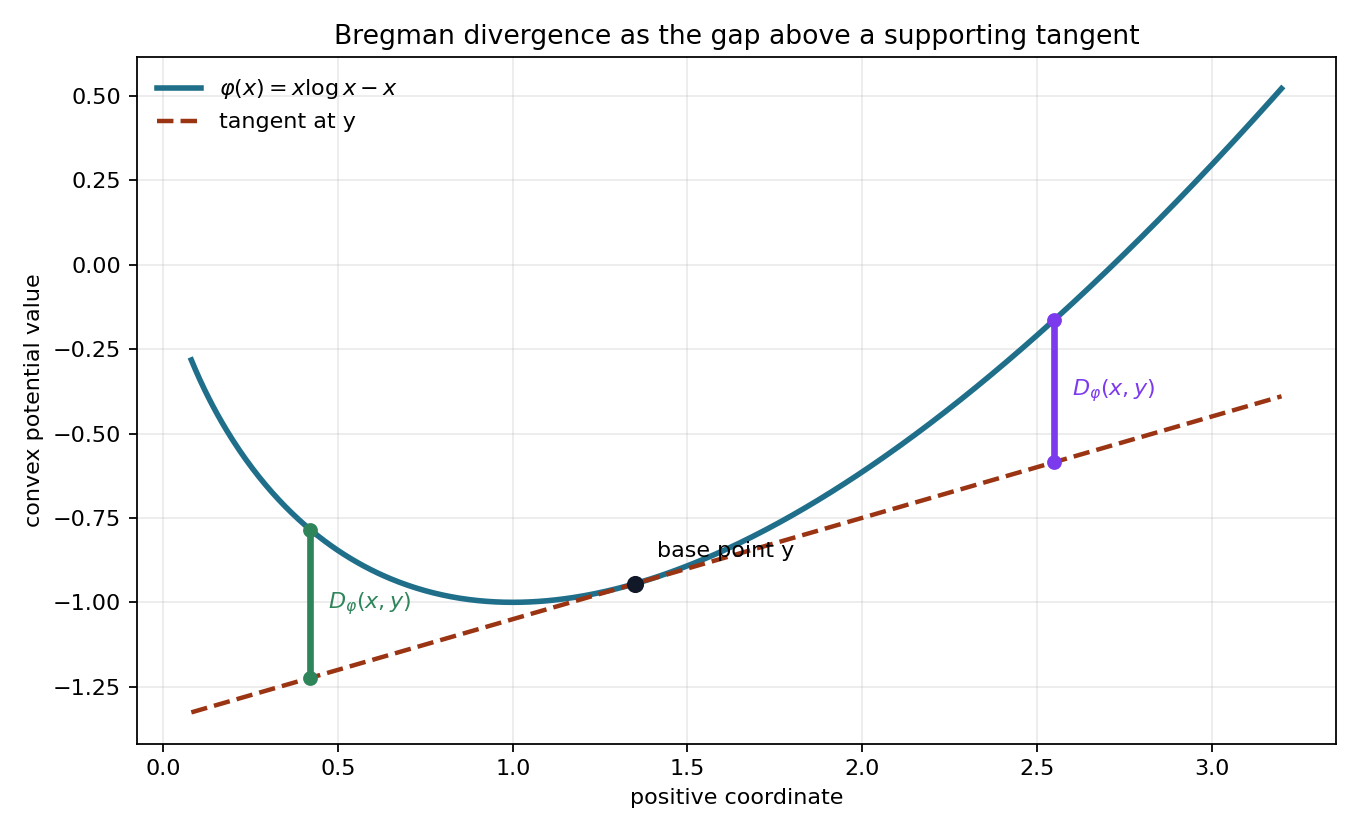

In [3]:
display_artifact(ARTIFACT_DIR / 'bregman_tangent_gap.png', width=760)

## 2. Worked examples of Bregman divergence

Two potentials are especially useful throughout information geometry.

**Quadratic potential.** If `phi(theta)=1/2 ||theta||^2`, then

$$
D_\varphi(x,y)=\frac12\|x-y\|^2.
$$

This is the familiar Euclidean case. It is symmetric only because the potential is quadratic with constant Hessian.

**Negative entropy potential.** On the positive orthant, let

$$
\varphi(x)=\sum_i x_i\log x_i - x_i.
$$

Then

$$
D_\varphi(x,y)=\sum_i x_i\log\frac{x_i}{y_i}-x_i+y_i.
$$

On the probability simplex, where the coordinates of both vectors sum to one, the linear terms cancel and the formula becomes the Kullback-Leibler divergence `KL(x || y)`. This is the first bridge from convex analysis to statistical geometry.

In [4]:
def bregman(phi, grad_phi, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(phi(x) - phi(y) - grad_phi(y) @ (x-y))

quad_phi = lambda z: 0.5*np.dot(z, z)
quad_grad = lambda z: z
xv = np.array([2.0, -1.0])
yv = np.array([-0.5, 0.5])

entropy_phi = lambda z: float(np.sum(z*np.log(z)-z))
entropy_grad = lambda z: np.log(z)
pdist = np.array([0.55, 0.30, 0.15])
qdist = np.array([0.20, 0.50, 0.30])

{
    'quadratic_bregman': bregman(quad_phi, quad_grad, xv, yv),
    'half_squared_euclidean': 0.5*np.sum((xv-yv)**2),
    'entropy_bregman': bregman(entropy_phi, entropy_grad, pdist, qdist),
    'kl_p_to_q': float(np.sum(pdist*np.log(pdist/qdist)))
}

{'quadratic_bregman': 4.25,
 'half_squared_euclidean': np.float64(4.25),
 'entropy_bregman': 0.2991607372093752,
 'kl_p_to_q': 0.29916073720937497}

## 3. Legendre duality: two linear views of one curved object

When the Hessian of a convex potential is positive definite, the gradient map

$$
\eta=\nabla\varphi(\theta)
$$

can be used as a coordinate change. The Legendre transform is

$$
\varphi^*(\eta)=\sup_\theta \{\langle\theta,\eta\rangle-\varphi(\theta)\}.
$$

At matching coordinates, the Fenchel-Young equality says

$$
\varphi(\theta)+\varphi^*(\eta)-\langle\theta,\eta\rangle=0.
$$

The pair `(theta, eta)` is dual: one coordinate system is natural for one family of flat curves, while the other is natural for the conjugate family. The Plotly surface below places gradient arrows on a convex potential, showing how `theta` points are sent into dual directions.

In [5]:
display_artifact(ARTIFACT_DIR / 'legendre_dual_surface.html')

A useful identity swaps the order of the arguments when passing to the dual potential:

$$
D_\varphi(\theta_1,\theta_2)=D_{\varphi^*}(\eta_2,\eta_1),
\quad \eta_i=\nabla\varphi(\theta_i).
$$

That reversal is the algebraic clue behind the two affine geometries.

In [6]:
def D_exp(th, ps):
    th=np.asarray(th); ps=np.asarray(ps)
    return float(np.sum(np.exp(th) - np.exp(ps) - np.exp(ps)*(th-ps)))

def D_star(eta2, eta1):
    eta2=np.asarray(eta2); eta1=np.asarray(eta1)
    return float(np.sum(eta2*np.log(eta2)-eta2 - (eta1*np.log(eta1)-eta1) - np.log(eta1)*(eta2-eta1)))

th1=np.array([-.4,.7,1.2]); th2=np.array([.2,-.1,.9])
eta1=np.exp(th1); eta2=np.exp(th2)
D_exp(th1, th2), D_star(eta2, eta1), abs(D_exp(th1, th2)-D_star(eta2, eta1))

(0.6894371760098336, 0.6894371760098335, 1.1102230246251565e-16)

## 4. Projection and the generalized Pythagorean theorem

A projection is not merely the nearest point by a symmetric distance. With a divergence, the side from which we measure matters. A point `q` is a Bregman projection of `p` onto a set `M` when it minimizes `D(p, r)` over `r in M`.

For the quadratic potential, this reduces to ordinary orthogonal projection. The identity

$$
D(p,r)=D(p,q)+D(q,r)
$$

holds when `q` is the projection of `p` onto an affine set and `r` is any point in that set. In nonquadratic cases the picture bends, but the theorem keeps the same bookkeeping role when the relevant primal and dual flatness conditions are met.

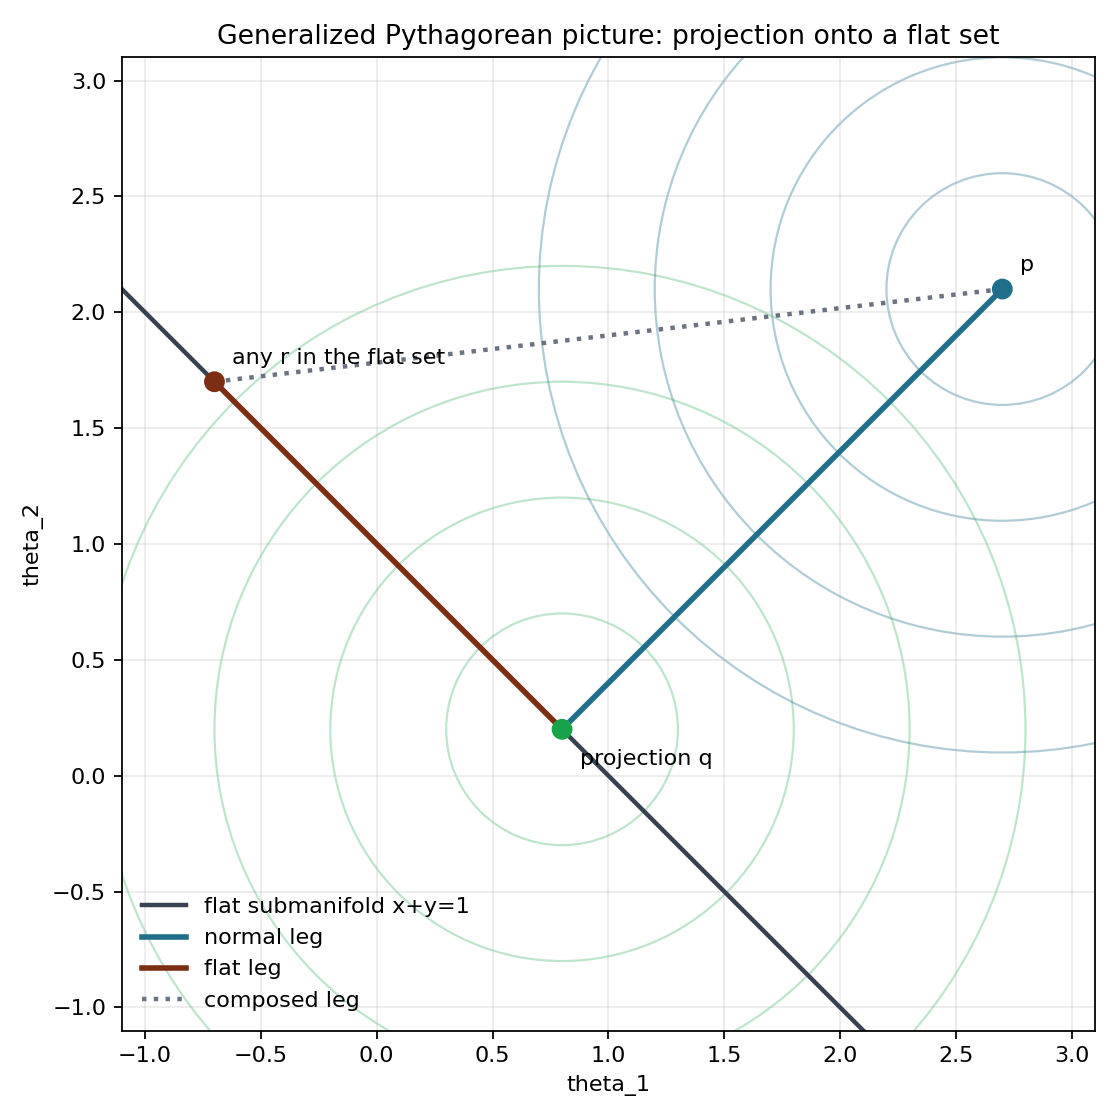

In [7]:
display_artifact(ARTIFACT_DIR / 'pythagorean_projection.png', width=720)

In [8]:
D = lambda x,y: 0.5*float(np.sum((np.asarray(x)-np.asarray(y))**2))
{
    'D(p,r)': D(p,r),
    'D(p,q)+D(q,r)': D(p,q)+D(q,r),
    'gap': abs(D(p,r)-D(p,q)-D(q,r))
}

{'D(p,r)': 5.860000000000001, 'D(p,q)+D(q,r)': 5.860000000000001, 'gap': 0.0}

## 5. Applied lab: projecting a categorical prior onto a moment constraint

Suppose a three-state variable has values `0, 1, 2`. We start from a prior distribution

$$
p=(0.20,0.50,0.30)
$$

and want the closest distribution `q` whose expected value is `1.25`, using `KL(q || p)`. The constrained minimizer has the exponential-tilt form

$$
q_i(\lambda)=\frac{p_i\exp(\lambda v_i)}{\sum_j p_j\exp(\lambda v_j)}.
$$

The scalar `lambda` is chosen so that the moment constraint is exactly met. This is an information-geometric projection: a prior is moved onto a flat constraint family by changing the dual coordinate associated with the statistic.

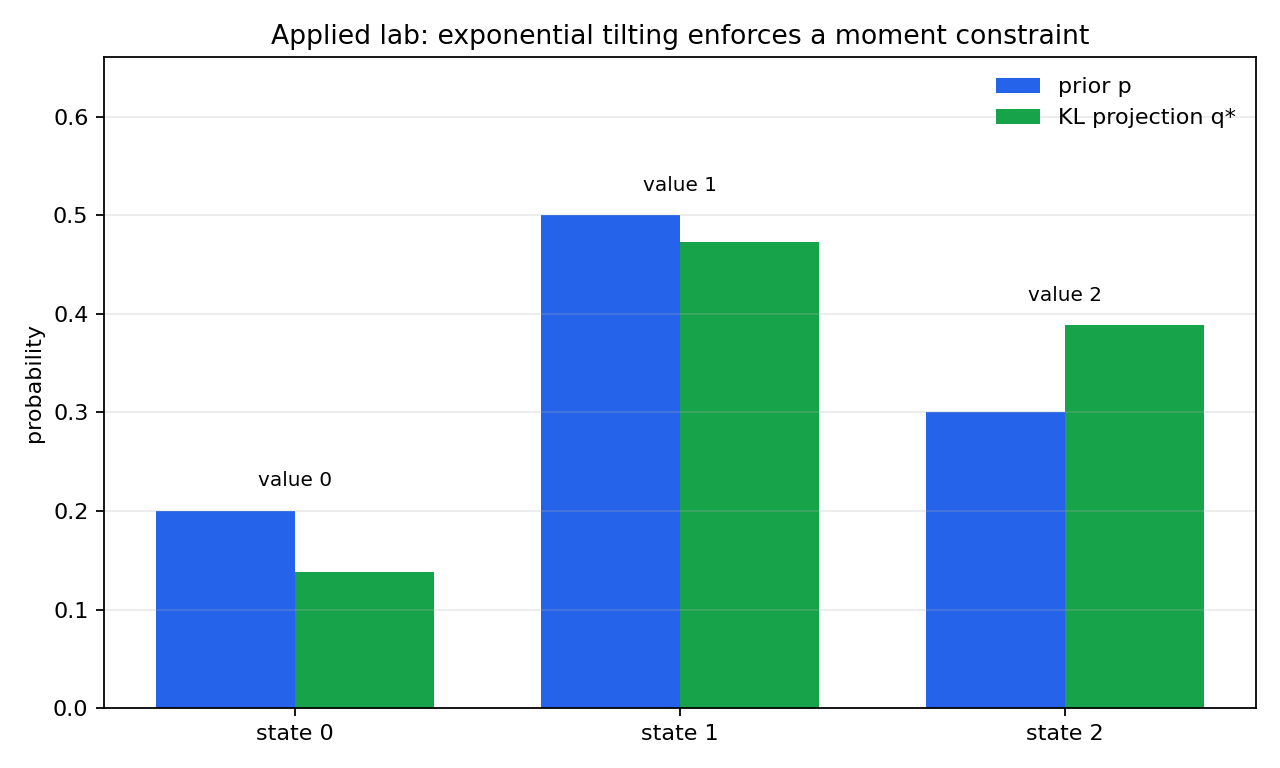

In [9]:
display_artifact(ARTIFACT_DIR / 'kl_moment_projection.png', width=760)

In [10]:
display_artifact(ARTIFACT_DIR / 'kl_simplex_projection.html')

In [11]:
{
    'prior': prior,
    'projection': qstar,
    'target_mean': target_mean,
    'achieved_mean': float(values@qstar),
    'KL(projection || prior)': float(np.sum(qstar*np.log(qstar/prior)))
}

{'prior': array([0.2, 0.5, 0.3]),
 'projection': array([0.13838554, 0.47322891, 0.38838554]),
 'target_mean': 1.25,
 'achieved_mean': 1.25,
 'KL(projection || prior)': 0.02328235854538943}

## 6. Pitfalls to watch

- A divergence can be locally metric-like without being globally distance-like.
- `D(p, q)` and `D(q, p)` usually answer different modeling questions.
- Legendre duality reverses Bregman arguments; forgetting the reversal breaks many projection identities.
- Projection statements need the right flatness assumptions. The Euclidean drawing is a guide to the bookkeeping, not proof that every curved family behaves like a line in the same coordinates.
- On the boundary of the probability simplex, entropy gradients may diverge. Many clean formulas live naturally on the positive interior.

## 7. Final sanity checks

The notebook closes by checking the core algebraic identities and verifying that the generated artifacts exist with nonzero size. The resulting JSON file is saved as `artifacts/chapter-01/final_sanity.json`.

In [12]:
def D_exp(th, ps):
    th=np.asarray(th); ps=np.asarray(ps)
    return float(np.sum(np.exp(th) - np.exp(ps) - np.exp(ps)*(th-ps)))

def D_star(eta2, eta1):
    eta2=np.asarray(eta2); eta1=np.asarray(eta1)
    return float(np.sum(eta2*np.log(eta2)-eta2 - (eta1*np.log(eta1)-eta1) - np.log(eta1)*(eta2-eta1)))

th1=np.array([-.4,.7,1.2]); th2=np.array([.2,-.1,.9])
eta1=np.exp(th1); eta2=np.exp(th2)
fenchel_gap=float(np.sum(np.exp(th1)) + np.sum(eta1*np.log(eta1)-eta1) - th1@eta1)
dual_gap=abs(D_exp(th1, th2) - D_star(eta2, eta1))
D = lambda x,y: 0.5*float(np.sum((np.asarray(x)-np.asarray(y))**2))
pyth_gap=abs(D(p,r) - D(p,q) - D(q,r))
artifact_files=['bregman_tangent_gap.png','pythagorean_projection.png','kl_moment_projection.png','legendre_dual_surface.html','kl_simplex_projection.html']
artifact_sizes={name:(ARTIFACT_DIR/name).stat().st_size for name in artifact_files}
final_sanity = {
    'chapter': '01-manifold-divergence-dually-flat-structure',
    'source_orientation': {'printed_pages':'3-30','pdf_pages':'16-43'},
    'fenchel_young_gap_exp_potential': fenchel_gap,
    'bregman_duality_gap_exp_entropy': dual_gap,
    'quadratic_pythagorean_gap': pyth_gap,
    'kl_projection': {'prior': prior.tolist(), 'target_mean': target_mean, 'lambda': float(lam), 'projection': qstar.tolist(), 'achieved_mean': float(values@qstar), 'constraint_error': abs(float(values@qstar)-target_mean)},
    'artifact_sizes': artifact_sizes,
    'all_checks_passed': bool(abs(fenchel_gap)<1e-12 and dual_gap<1e-12 and pyth_gap<1e-12 and abs(float(values@qstar)-target_mean)<1e-12 and all(s>1000 for s in artifact_sizes.values()))
}
(ARTIFACT_DIR/'final_sanity.json').write_text(json.dumps(final_sanity, indent=2), encoding='utf8')
assert final_sanity['all_checks_passed']
final_sanity

{'chapter': '01-manifold-divergence-dually-flat-structure',
 'source_orientation': {'printed_pages': '3-30', 'pdf_pages': '16-43'},
 'fenchel_young_gap_exp_potential': 0.0,
 'bregman_duality_gap_exp_entropy': 1.1102230246251565e-16,
 'quadratic_pythagorean_gap': 0.0,
 'kl_projection': {'prior': [0.2, 0.5, 0.3],
  'target_mean': 1.25,
  'lambda': 0.3132449107715968,
  'projection': [0.13838554396786476,
   0.47322891206427076,
   0.38838554396786457],
  'achieved_mean': 1.25,
  'constraint_error': 0.0},
 'artifact_sizes': {'bregman_tangent_gap.png': 86658,
  'pythagorean_projection.png': 150859,
  'kl_moment_projection.png': 34817,
  'legendre_dual_surface.html': 205749,
  'kl_simplex_projection.html': 169940},
 'all_checks_passed': True}

In [13]:
display_artifact(ARTIFACT_DIR / 'final_sanity.json')

<IPython.core.display.JSON object>

## Takeaways

Bregman divergence is the gap between a convex potential and a tangent approximation. That single construction recovers squared Euclidean distance, KL divergence on the simplex, and the projection geometry used in statistical modeling.

Legendre duality turns the gradient of the potential into a coordinate transform. In information geometry, the primal and dual coordinates support complementary notions of flatness.

The generalized Pythagorean theorem is the operational heart of the chapter: after the correct projection, divergence from `p` to any admissible `r` decomposes into a projection cost plus an in-family cost.

The applied lab shows the same mechanism in a small statistical task: KL projection of a prior onto a moment constraint is exponential tilting.

## Standalone Synthesis

The chapter focus is: Manifolds, asymmetric divergence, Bregman geometry, Legendre duality, affine coordinates, and generalized Pythagorean projection.

Key computational translations:

- a coordinate chart is a computational handle, not the manifold itself. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- a divergence compares two points without requiring symmetry. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- a convex potential creates dual coordinates through the Legendre transform. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- orthogonal e- and m-projections turn the Pythagorean theorem into an algorithm. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- probability-simplex chart comparing e-geodesics and m-geodesics. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- Bregman tangent-plane gap animation. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- dual-coordinate grid over a convex potential. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- alternating projection path with divergence values annotated. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 3-30; PDF pages 20-47. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-01` using the chapter's local sanity JSON naming convention.


In [ ]:
from pathlib import Path

def _discover_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise RuntimeError('Could not locate book root')

BOOK_ROOT = _discover_book_root(Path.cwd())
BOOK_ROOT
